# NLP Project, Classification of Amazon Reviews and Key Phrases
#### CSCI 3832 Natural Language Processing
Members: Adam Wuth, Benjamin Kohav, Noah Vilas, Aiden Devine, Evan Zachary

### Requirements

In [1]:
import os, random, sys, copy
import torch, torch.nn as nn, numpy as np
from tqdm.notebook import tqdm
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from nltk.tokenize import word_tokenize
from datasets import load_dataset, concatenate_datasets, load_from_disk
from datetime import datetime

### Load in the data set
The dataset is split into categories, but we wanted all categories from 2020 onwards. This code block will take forever to run, only run it the first time to get the dataset. 

In [2]:
#The dataset is split into categories

categories = [
    "All_Beauty",
    "Amazon_Fashion",
#     "Appliances",
#     "Arts_Crafts_and_Sewing",
#     "Automotive",
#     "Baby_Products",
#     "Beauty_and_Personal_Care",
#     "Books",
#     "CDs_and_Vinyl",
#     "Cell_Phones_and_Accessories",
#     "Clothing_Shoes_and_Jewelry",
#     "Digital_Music",
#     "Electronics",
#     "Gift_Cards",
#     "Grocery_and_Gourmet_Food",
#     "Handmade_Products",
#     "Health_and_Household",
#     "Health_and_Personal_Care",
#     "Home_and_Kitchen",
#     "Industrial_and_Scientific",
#     "Kindle_Store",
#     "Magazine_Subscriptions",
#     "Movies_and_TV",
#     "Musical_Instruments",
#     "Office_Products",
#     "Patio_Lawn_and_Garden",
#     "Pet_Supplies",
#     "Software",
#     "Sports_and_Outdoors",
#     "Subscription_Boxes",
#     "Tools_and_Home_Improvement",
#     "Toys_and_Games",
    "Video_Games",
    "Unknown"
]

#to get reviews from 2023 onwards 2020 onwards was millions of reviews and was taking
#over an hour just to load the data
start_timestamp = int(datetime(2023, 1, 1).timestamp() * 1000)

#to store all datasets
allcats = []

for cat in categories:
    print(f"Loading category: {cat}")
    dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", f"raw_review_{cat}", split="full[:150000]",  trust_remote_code=True)
    #dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", f"raw_review_{cat}", split="full[:1%]",  trust_remote_code=True)
   #dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", cat, split="full",  trust_remote_code=True) formatting issues
    #get the 2023 onwards and add to data
    filtered_dataset = dataset.filter(lambda x: x['timestamp'] >= start_timestamp)
    #allcats.append(dataset)
    allcats.append(filtered_dataset)
#make one final dataset    
reviews = concatenate_datasets(allcats)

print(f"Total reviews loaded: {len(reviews)}")

reviews.save_to_disk("filetred_amazon_reviews")


Loading category: All_Beauty
Loading category: Amazon_Fashion
Loading category: Video_Games
Loading category: Unknown
Total reviews loaded: 7276


Saving the dataset (0/1 shards):   0%|          | 0/7276 [00:00<?, ? examples/s]

If you have run that already, reviews was saved(should be in the working directory)so you can just do the next code block instead

In [3]:
reviews = load_from_disk("filetred_amazon_reviews")
print(len(reviews))
print(reviews[0])
print(reviews[1])
print(reviews.column_names)

7276
{'rating': 1.0, 'title': 'halo hair extensions', 'text': "This halo hair extension is simply put, garbage.  Now, you get what you pay for.  And this is a very cheap version.  The faux hair is very shiny and looks literally like bad barbie hair.  It looks WAY better in the photos than in real life.  The color is horrific, in my opinion of course.  The streaks are like paint strips.  And all of that would be one thing - but the worst is that the hair completely fell out!  I had hand fulls of hair strands just trying to put the halo on!  And you might think - well, maybe a little loss is to be expected?  Except this was handfuls and handfuls.  I literally dropped the whole thing right into the trash.  I would say this one is a pass for hair loss alone.  Having said all of this, I never hesitate to update my reviews should new info seem useful. All of my reviews reflect my honest, personal experience with the reviewed item - your experience may be different. I am not influenced by any

### Load in the Glove Embeddings

In [4]:
glove_file = '../glove.6B.50d.txt' # modify to appropriate path for your file system

embeddings_dict = {}

with open(glove_file, 'r', encoding='utf8') as f:
    for i, line in enumerate(f):
        line = line.strip().split(' ')
        word = line[0]
        embed = np.asarray(line[1:], "float")

        embeddings_dict[word] = embed


print('Loaded {} words from glove'.format(len(embeddings_dict)))

low = -1.0 / 3
high = 1.0 / 3
embedding_matrix = np.random.uniform(low=low, high=high, size=(len(embeddings_dict)+1, 50))

word2id = {}
for i, word in enumerate(embeddings_dict.keys(), 1):

    word2id[word] = i                                
    embedding_matrix[i] = embeddings_dict[word]      

word2id['<pad>'] = 0

Loaded 400000 words from glove


### Set up train and validation datasets

In [5]:
#modified from the HW_3 
class RNNMovieReviewDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset=None, word2id=None, finalized_data=None, data_limit=250, max_length=128):
        """
        :param hf_dataset: A Hugging Face Dataset object (preloaded and filtered)
        :param word2id: The GloVe word2id dictionary
        :param finalized_data: Used to create validation set
        :param data_limit: Max number of examples to use
        :param max_length: Max sequence length
        """
        self.data_limit = data_limit
        self.max_length = max_length
        self.word2id = word2id

        if finalized_data:
            self.data = finalized_data
        else:
            examples = []
            labels = []

            for i, example in enumerate(hf_dataset):
                if i >= self.data_limit:
                    break
                examples.append(example["text"])
                labels.append(int(example["rating"]) - 1)  # 1–5 stars → 0–4

            tokenized = self.tokenize(examples)
            self.data = [(ids, length, label) for (ids, length), label in zip(tokenized, labels)]
            random.seed(42)
            random.shuffle(self.data)

    def tokenize(self, examples):
        example_ids = []
        misses = 0
        total = 0
        for example in tqdm(examples):
            tokens = word_tokenize(example)
            ids = []
            for tok in tokens:
                if tok in self.word2id:
                    ids.append(self.word2id[tok])
                else:
                    misses += 1
                    ids.append(self.word2id.get('unk', 0))
                total += 1

            if len(ids) >= self.max_length:
                ids = ids[:self.max_length]
                length = self.max_length
            else:
                length = len(ids)
                ids += [self.word2id['<pad>']] * (self.max_length - len(ids))

            example_ids.append((torch.tensor(ids), length))

        print(f'Missed {misses} out of {total} words -- {misses/total:.2%}')
        return example_ids

    def generate_validation_split(self, ratio=0.8):
        split_idx = int(ratio * len(self.data))
        val_split = self.data[split_idx:]
        self.data = self.data[:split_idx]
        return val_split

    def __getitem__(self, index):
        return self.data[index]  # returns (input_ids, length, label)

    def __len__(self):
        return len(self.data)


In [6]:
#also modified from hw3
train_dataset = RNNMovieReviewDataset(hf_dataset=reviews, word2id=word2id, data_limit=100000)
validation_examples = train_dataset.generate_validation_split()
print('Loaded {} train examples'.format(len(train_dataset)))

valid_dataset = RNNMovieReviewDataset(finalized_data=validation_examples, word2id=word2id)
print('Loaded {} validation examples'.format(len(valid_dataset)))

print(valid_dataset[0])  # (input_ids, length, label)

  0%|          | 0/7276 [00:00<?, ?it/s]

Missed 46395 out of 414142 words -- 11.20%
Loaded 5820 train examples
Loaded 1456 validation examples
(tensor([201535,    269,    232,     15, 128102,      6,    851,     20,  13635,
             3, 201535,    627,      2,    318,      3, 201535,   3633,      3,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,  

In [7]:
input_ids, length, label = valid_dataset[1]
print("True length:", length)
print("Non-padded input:", input_ids[:length])
print("Label:", label)


True length: 1
Non-padded input: tensor([72925])
Label: 4



**Building Bigram and Trigram Models
Step 1: Preprocessing the Text**

Tokenization: Use nltk.word_tokenize() to break each review into word tokens.

Lowercasing: Make all tokens lowercase.

Padding: Ensure each review is exactly 256 words, either by truncating or padding with PAD.

In [10]:
# Creating unsup reviews so there is no data on the star rating given to the review

from datasets import load_dataset
import random

from datasets import concatenate_datasets
import random

# Assuming you've already run this and have your filtered dataset:
# reviews = concatenate_datasets(allcats)

# Shuffle and select 15,000 reviews
reviews_shuffled = reviews.shuffle(seed=42)
# unsup_examples = [entry['review_text'] for entry in reviews_shuffled.select(range(15000))]
unsup_examples = [entry['text'] for entry in reviews_shuffled.select(range(7000))]


**2. Tokenize the Unlabeled Reviews Using Your Vocabulary**

Tokenization block, adjusted for our setup (with padding and your own vocabulary):

In [14]:
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize
from tqdm import tqdm

from collections import Counter
from nltk.tokenize import word_tokenize

# Extract texts (e.g., the 'review_body' field)
texts = [r['text'] for r in reviews]  # reviews is your HuggingFace dataset

# Tokenize and lowercase
all_tokens = []
for text in texts:
    tokens = word_tokenize(text.lower())
    all_tokens.extend(tokens)

# Build a frequency counter
token_freq = Counter(all_tokens)

# Limit to top 5000 (or other size)
vocab_size = 5000
most_common_tokens = [token for token, _ in token_freq.most_common(vocab_size)]

# Add special tokens
special_tokens = ['<pad>', '<s>', '</s>', '<unk>']
vocabulary = {token: idx for idx, token in enumerate(special_tokens + most_common_tokens)}



# taken homework 2 
sos_id = vocabulary['<s>']
eos_id = vocabulary['</s>']
unk_id = vocabulary['<unk>']

# Tokenize and convert to IDs
tokenized_examples = []

for example in tqdm(unsup_examples):
    example_tokens = [token.lower() for token in word_tokenize(example)]
    
    token_ids = [sos_id]
    for token in example_tokens:
        token_ids.append(vocabulary.get(token, unk_id))
    token_ids.append(eos_id)

    # Pad or trim to max length
    if len(token_ids) < 256:
        token_ids += [vocabulary['<pad>']] * (256 - len(token_ids))
    else:
        token_ids = token_ids[:256]

    tokenized_examples.append(token_ids)


[nltk_data] Downloading package punkt to /home/beko8392/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
100%|██████████| 7000/7000 [00:02<00:00, 3059.01it/s]


In [15]:
import torch

class BigramDataset(torch.utils.data.Dataset):

    def __init__(self, tokenized_data):

        self.examples = []
        for example in tokenized_data:              #Iterate over our dataset
            for i in range(0,len(example) - 1):     #Iterate over the tokens of the example
                '''
                    Your code here.

                    Bigrams should be a tuple of integers: (example[i], example[i+1])
                    For each bigram, if either of example[i] or example[i+1] are unknown then do not add the bigram to our examples.

                    10 pts.
                '''
                bigram = (example[i], example[i+1]) # Create bigram tuple
                if unk_id not in bigram:            # Only add if no unknown token
                    self.examples.append(bigram)
                        
                        
    def __getitem__(self, idx):

        return self.examples[idx]

    def __len__(self):

        return len(self.examples)


import torch.nn as nn

class BigramLM(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_hidden_layers):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.hidden_layer_1 = nn.Linear(embedding_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(num_hidden_layers - 1)])
        self.output_layer = nn.Linear(hidden_dim, vocab_size)

        self.relu = nn.ReLU()

    def forward(self, input):

        embedding = self.embedding(input)

        hidden = self.relu(self.hidden_layer_1(embedding))

        for layer in self.hidden_layers:
            hidden = self.relu(layer(hidden))

        output = self.output_layer(hidden)

        return output

In [16]:
# Training Loop

#Initialize our model -- keep it small with 1 hidden layer, and embedding sizes of 50
bigram_model = BigramLM(len(vocabulary), 50, 50, 1)

#Initialize our dataset using a subset of examples
bigram_dataset = BigramDataset(tokenized_examples[:5000])

criteria = nn.CrossEntropyLoss()
#AdamW is a popularly used optimizer
optimizer = torch.optim.AdamW(bigram_model.parameters())  
#Either of these optimizers could be used
# optimizer = torch.optim.SGD(bigram_model.parameters(), lr=0.5)   

# softmax = nn.Softmax(dim=1)

epochs = 3
batch_size = 32
print_frequency = 1000

#We'll create an instance of a torch dataloader to collate our data. This class handles batching and shuffling (should be done each epoch)
train_dataloader = torch.utils.data.DataLoader(bigram_dataset, batch_size=batch_size, shuffle=True)


# store average loss values
avg_loss_values = []

for i in range(epochs):
    print('### Epoch: ' + str(i+1) + ' ###')

    bigram_model.train()
    avg_loss = 0
    
    
    # ADDED Store loss for plotting
    loss_history = []  

    for step, data in enumerate(train_dataloader):

        x, y = data

        optimizer.zero_grad()

        model_output = bigram_model(x)
#         model_output_probabilities = softmax(model_output)

        loss = criteria(model_output.squeeze(1), y)

        loss.backward()
        optimizer.step()

        avg_loss += loss.item()
        if step % print_frequency == 1:
            # ADDED add loss to history before resetting
            avg_loss_values.append(avg_loss / print_frequency) 
            print('epoch: {} batch: {} loss: {}'.format(
                i,
                step,
                avg_loss / print_frequency
            ))
            avg_loss = 0

### Epoch: 1 ###
epoch: 0 batch: 1 loss: 0.016456936836242674
epoch: 0 batch: 1001 loss: 1.506312753014383
epoch: 0 batch: 2001 loss: 1.1598301497382926
epoch: 0 batch: 3001 loss: 1.1364143239553668
epoch: 0 batch: 4001 loss: 1.0862946751688287
epoch: 0 batch: 5001 loss: 1.114094672552077
epoch: 0 batch: 6001 loss: 1.1202938772514464
epoch: 0 batch: 7001 loss: 1.089496239706874
epoch: 0 batch: 8001 loss: 1.0908938688337804
epoch: 0 batch: 9001 loss: 1.0721556430787422
epoch: 0 batch: 10001 loss: 1.0521046133424534
epoch: 0 batch: 11001 loss: 1.0825387900887908
epoch: 0 batch: 12001 loss: 1.0655467856302858
epoch: 0 batch: 13001 loss: 1.1071241453662515
epoch: 0 batch: 14001 loss: 1.0803668997059412
epoch: 0 batch: 15001 loss: 1.086927990451433
epoch: 0 batch: 16001 loss: 1.062576315905897
epoch: 0 batch: 17001 loss: 1.0727387312464094
epoch: 0 batch: 18001 loss: 1.087607585970239
epoch: 0 batch: 19001 loss: 1.0509152657091618
epoch: 0 batch: 20001 loss: 1.0378052522092764
epoch: 0 batc

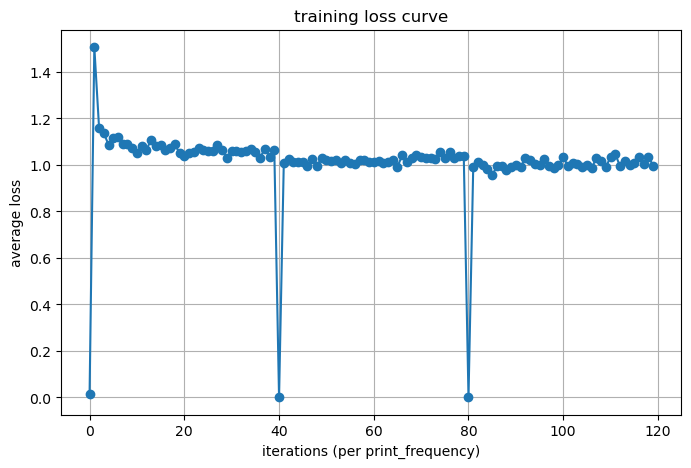

In [19]:
import os, random, sys, matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(avg_loss_values, marker='o', linestyle='-')
plt.xlabel('iterations (per print_frequency)')
plt.ylabel('average loss')
plt.title('training loss curve')
plt.grid()
plt.show()